In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

### Step1: Load Data

In [3]:
df=pd.read_csv(r"C:\Users\bodhe\Downloads\insurance (1).csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
print('='*60)
print('Sprint 1 - Exploratory Data Analysis')
print('='*60)

Sprint 1 - Exploratory Data Analysis


### Step 2: Basic Overview

In [5]:
print('\n--- Shape ---')
print(f'Rows:{df.shape[0]}, Columns:{df.shape[1]}')


--- Shape ---
Rows:1338, Columns:7


In [6]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [7]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [8]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [10]:
print('\n--- Unique Values in Categorical Columns ---')
for col in ['sex','smoker','region']:
    print(f'{col}: {df[col].unique()}')


--- Unique Values in Categorical Columns ---
sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


### Step 3: Data Distribution of Each Column

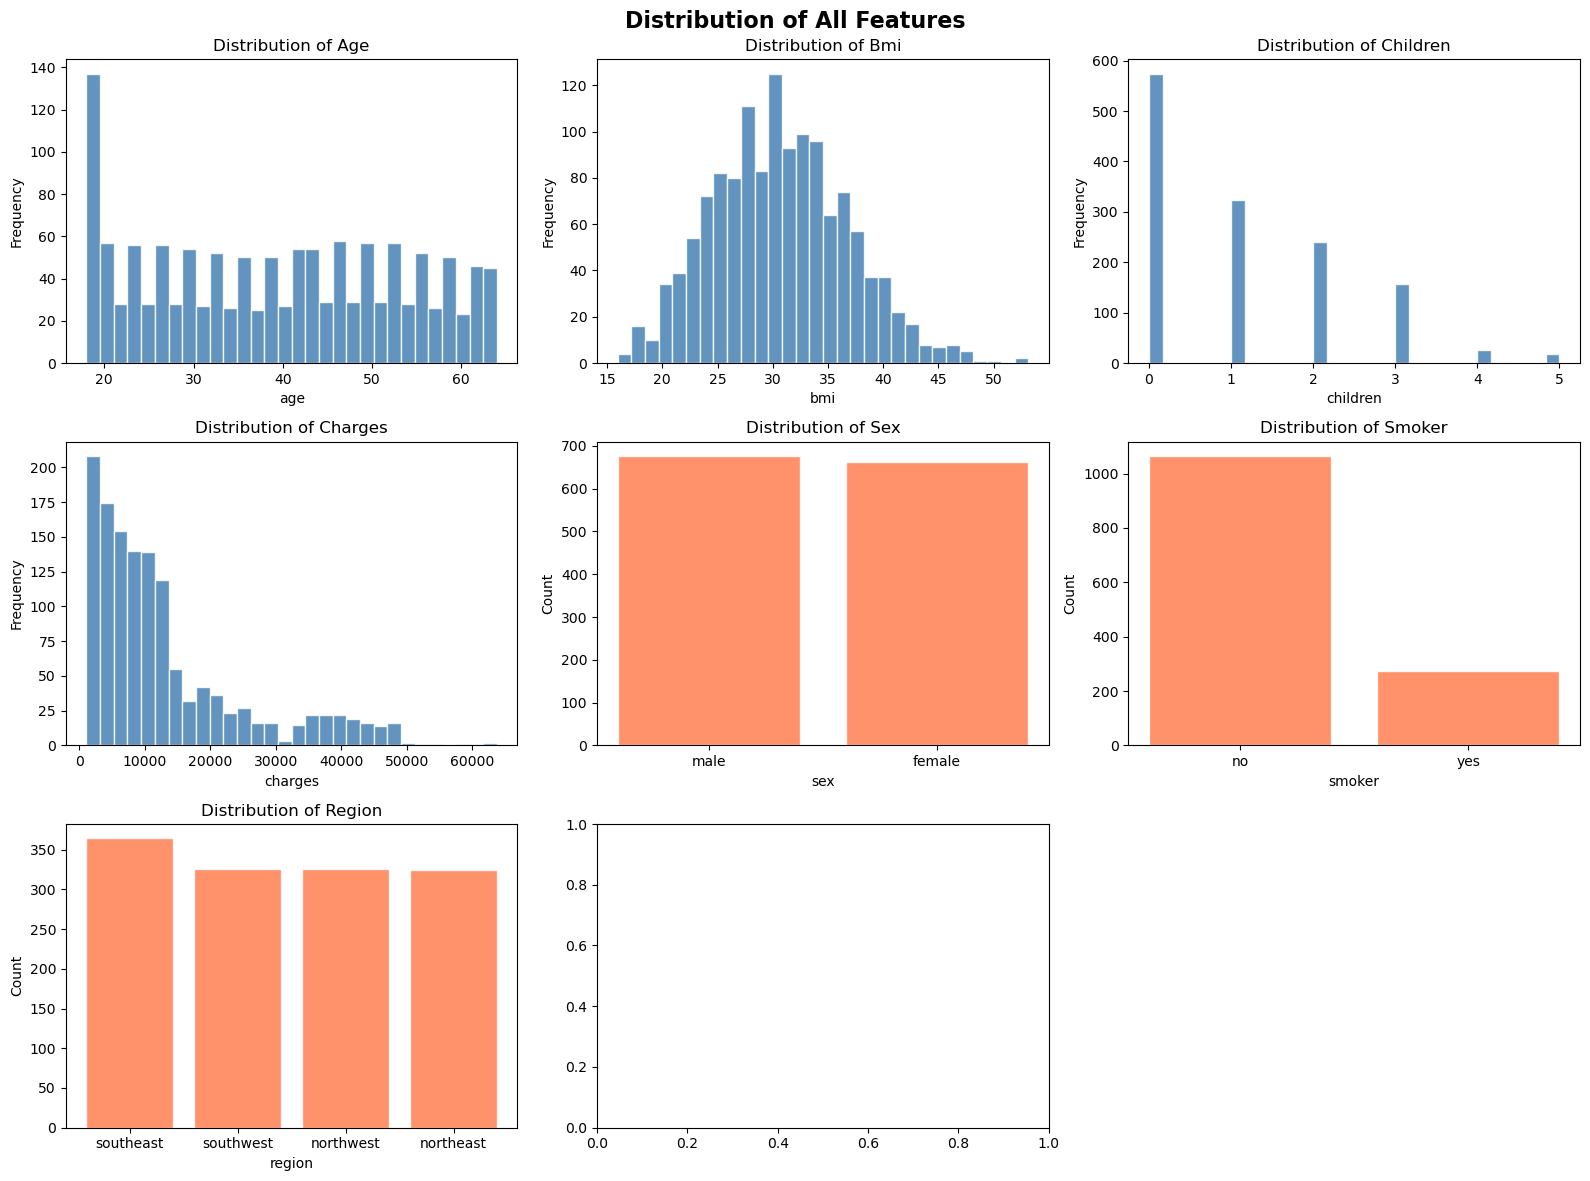


[Saved] sprint1_distributions.png


In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Distribution of All Features", fontsize=16, fontweight='bold')
 
# Numerical columns - histograms
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col.capitalize()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
 
# Categorical columns - bar plots
cat_cols = ['sex', 'smoker', 'region']
for i, col in enumerate(cat_cols):
    ax = axes[(4 + i) // 3][(4 + i) % 3]
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='coral', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col.capitalize()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
 
# Remove unused subplot
axes[2][2].axis('off')
 
plt.tight_layout()
plt.savefig('sprint1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved] sprint1_distributions.png")

### Step4: Identify Significant Variable vs Target(charges)

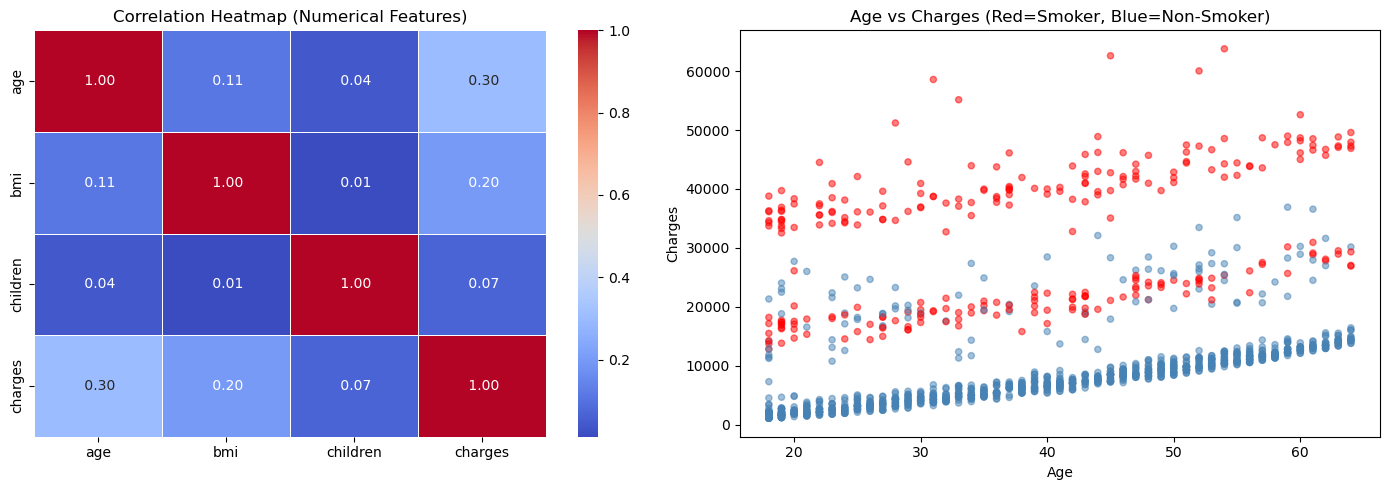

[Saved] sprint1_correlation.png


In [12]:
fig, axes= plt.subplots(1,2, figsize=(14,5))
# 4a. Correlation Heatmap (numerical features)
corr=df[['age', 'bmi','children', 'charges']].corr()
sns.heatmap(corr, annot=True, fmt=' .2f',cmap='coolwarm', ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlation Heatmap (Numerical Features)')
# 4b. Scatter: Age vs Charges (colored by smoker)
colors = df['smoker'].map({'yes': 'red', 'no': 'steelblue'})
axes[1].scatter(df['age'], df['charges'], c=colors, alpha=0.5, s=20)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Charges')
axes[1].set_title('Age vs Charges (Red=Smoker, Blue=Non-Smoker)')

plt.tight_layout()
plt.savefig('sprint1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] sprint1_correlation.png")



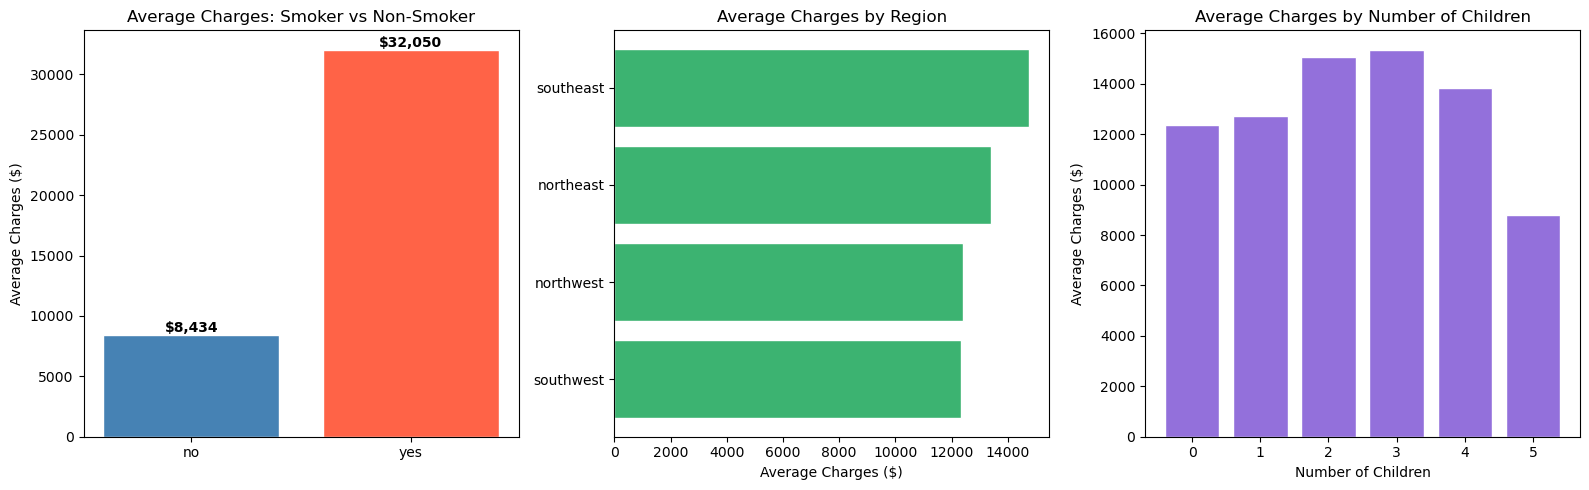

[Saved] sprint1_categorical_analysis.png


In [13]:
### Charges by Smoker Status
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# Smoker vs Charges
smoker_means = df.groupby('smoker')['charges'].mean()
axes[0].bar(smoker_means.index, smoker_means.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Average Charges: Smoker vs Non-Smoker')
axes[0].set_ylabel('Average Charges ($)')
for i, v in enumerate(smoker_means.values):
    axes[0].text(i, v + 200, f'${v:,.0f}', ha='center', fontweight='bold')
 
# Region vs Charges
region_means = df.groupby('region')['charges'].mean().sort_values()
axes[1].barh(region_means.index, region_means.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average Charges by Region')
axes[1].set_xlabel('Average Charges ($)')
 
# Children vs Charges
children_means = df.groupby('children')['charges'].mean()
axes[2].bar(children_means.index.astype(str), children_means.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Average Charges by Number of Children')
axes[2].set_xlabel('Number of Children')
axes[2].set_ylabel('Average Charges ($)')
 
plt.tight_layout()
plt.savefig('sprint1_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] sprint1_categorical_analysis.png")

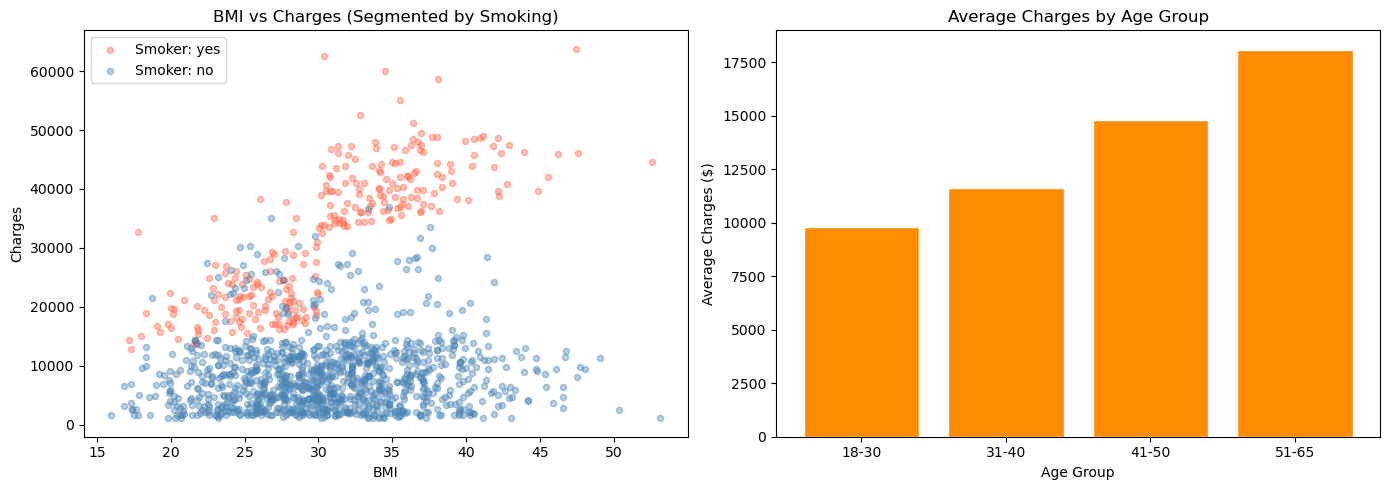

[Saved] sprint1_bmi_age_analysis.png


In [14]:
# 4d. BMI vs Charges with Smoker segmentation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for smoker_status, color in [('yes', 'tomato'), ('no', 'steelblue')]:
    subset = df[df['smoker'] == smoker_status]
    axes[0].scatter(subset['bmi'], subset['charges'], color=color,
                    alpha=0.4, s=20, label=f'Smoker: {smoker_status}')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges')
axes[0].set_title('BMI vs Charges (Segmented by Smoking)')
axes[0].legend()
 
# Age group analysis
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 65], labels=['18-30', '31-40', '41-50', '51-65'])
age_charges = df.groupby('age_group')['charges'].mean()
axes[1].bar(age_charges.index, age_charges.values, color='darkorange', edgecolor='white')
axes[1].set_title('Average Charges by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Charges ($)')
 
plt.tight_layout()
plt.savefig('sprint1_bmi_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] sprint1_bmi_age_analysis.png")
 

### Step5: Insights & Recommendations

### KEY INSIGHTS & BUSINESS RECOMMENDATIONS

- #####  SMOKING IS THE STRONGEST PREDICTOR
  - Smokers incur on average $32,050 vs $8,434 for non-smokers
  - That's 3.8x higher charges
  - ##### RECOMMENDATION:
    - Apply significantly higher premiums for smokers.
    -  Offer wellness incentive programs to encourage smoking cessation.
 
- #####  AGE POSITIVELY CORRELATES WITH CHARGES
  - Correlation between age and charges: 0.30
  - Charges increase consistently with age
   - ###### RECOMMENDATION:
     - Use age-tiered pricing models.
     - Offer preventive care programs for individuals aged 40+.
 
  
- ##### HIGH BMI + SMOKING = EXTREME COSTS
  - Obese smokers (BMI > 30 + smoker) represent the highest cost segment
  - ###### RECOMMENDATION:
      - Create a BMI + Smoking composite risk score.
      - Target wellness programs toward high-BMI policyholders.
 
- #####  REGION HAS MINOR IMPACT
  - Regional variation in charges is small (~5-8%)
  - ##### RECOMMENDATION:
    -  Regional pricing adjustments are not critical,
    but could serve as a minor risk factor in models.
 
- #####  NUMBER OF CHILDREN IS WEAKLY CORRELATED
  - Correlation with charges: 0.07
  - ##### RECOMMENDATION:
     - Include children as a minor premium factor,
      but don't over-weight this variable.


#### Sprint-3: Data Preparation & Model Building

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [17]:
df=pd.read_csv(r"C:\Users\bodhe\Downloads\insurance (1).csv")

print("=" * 60)
print("SPRINT 3 - MODEL BUILDING")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nTarget variable (charges) stats:\n{df['charges'].describe()}")

SPRINT 3 - MODEL BUILDING

Shape: (1338, 7)
Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Target variable (charges) stats:
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


### STEP 2: Problem Documentation

- Input Variables  : age, sex, bmi, children, smoker, region
- Output Variable  : charges (continuous numerical)
- ML Task Type     : Regression
- Evaluation Metric: Mean Absolute Error (MAE)
-  → Lower MAE = Better predictions
-  → Also tracking R² Score for goodness-of-fit


### Step3: Train- Test- Split

In [18]:
X = df.drop('charges', axis=1)
y = df['charges']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
 
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 1003
Testing samples  : 335


### STEP 4 & 5: Data Preparation Pipeline

In [27]:

numerical_features   = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']
 

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])
 
print("\nPreprocessing Strategy:")
print("  Numerical  (age, bmi, children) → StandardScaler")
print("  Categorical (sex, smoker, region) → OneHotEncoding (drop first)")
 


Preprocessing Strategy:
  Numerical  (age, bmi, children) → StandardScaler
  Categorical (sex, smoker, region) → OneHotEncoding (drop first)


### STEP 6 & 7: Model Training & Evaluation

In [20]:

models = {
    'KNN Regressor'       : KNeighborsRegressor(n_neighbors=5),
    'Linear Regression'   : LinearRegression(),
    'SVR'                 : SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    'Decision Tree'       : DecisionTreeRegressor(random_state=42, max_depth=6),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
}
 
results = {}
 
print("\n" + "=" * 60)
print(f"{'Model':<25} {'MAE ($)':>12} {'R² Score':>12}")
print("=" * 60)
 
for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
 
    # Train
    pipe.fit(X_train, y_train)
 
    # Predict
    y_pred = pipe.predict(X_test)
 
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
 
    results[name] = {'MAE': mae, 'R2': r2, 'pipeline': pipe, 'predictions': y_pred}
    print(f"{name:<25} ${mae:>11,.2f} {r2:>12.4f}")
 
print("=" * 60)


Model                          MAE ($)     R² Score
KNN Regressor             $   3,963.38       0.6941
Linear Regression         $   4,243.65       0.7673
SVR                       $   6,327.37      -0.0191
Decision Tree             $   2,834.27       0.8166
Random Forest             $   2,637.35       0.8479


### STEP 8: Visualize Model Comparison

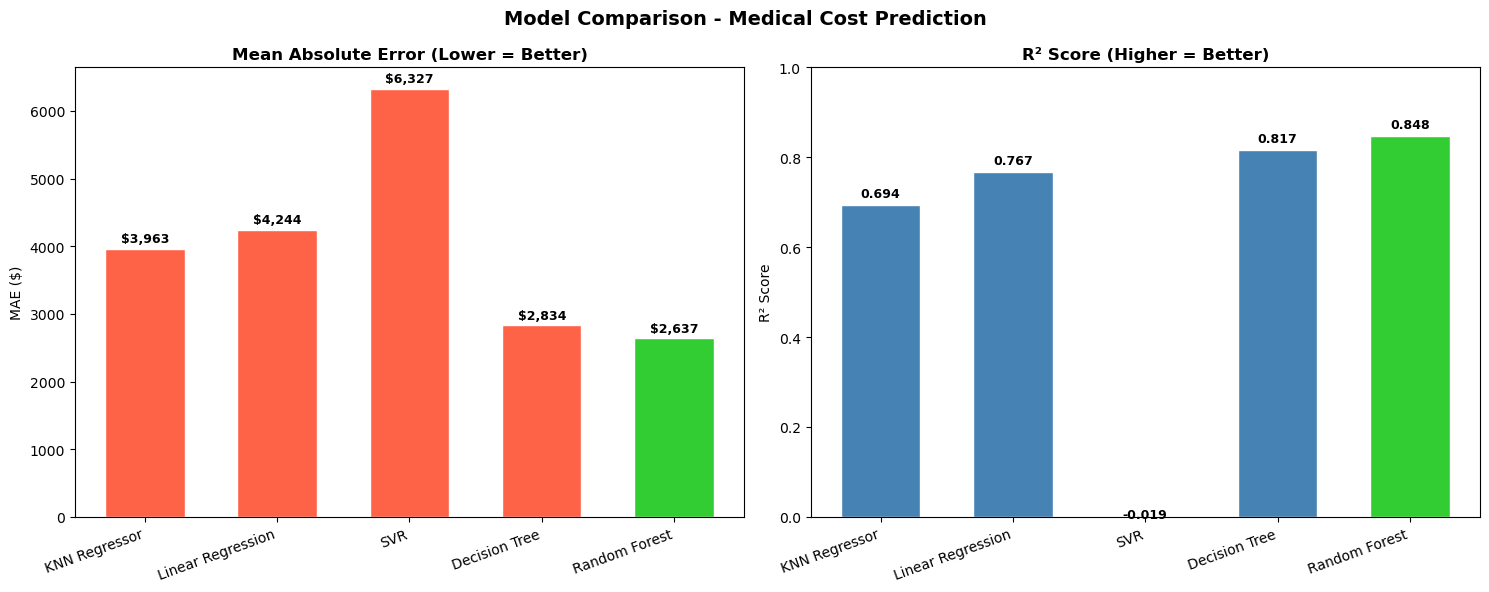


[Saved] sprint3_model_comparison.png


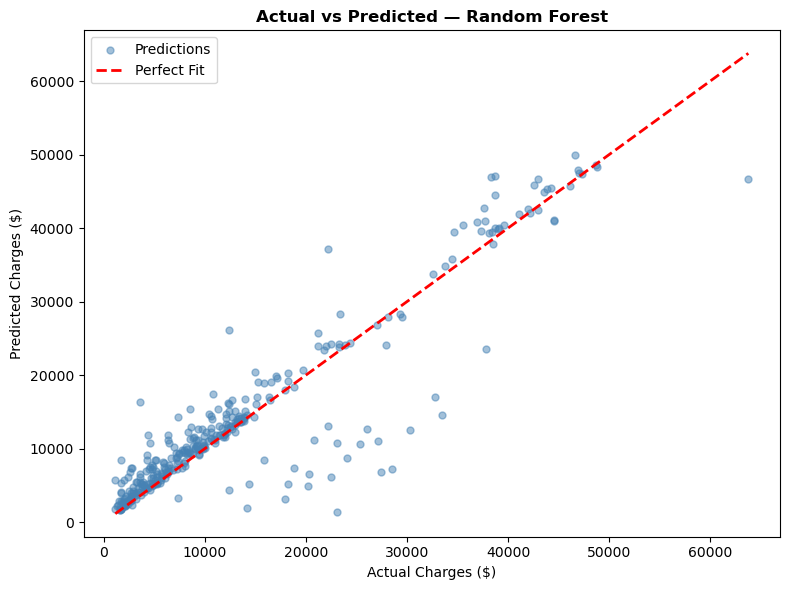

[Saved] sprint3_actual_vs_predicted.png


In [26]:


model_names = list(results.keys())
mae_scores  = [results[m]['MAE'] for m in model_names]
r2_scores   = [results[m]['R2']  for m in model_names]
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison - Medical Cost Prediction', fontsize=14, fontweight='bold')
 
# MAE Chart (lower is better)
colors = ['tomato' if m != min(model_names, key=lambda x: results[x]['MAE']) else 'limegreen'
          for m in model_names]
bars = axes[0].bar(model_names, mae_scores, color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Mean Absolute Error (Lower = Better)', fontweight='bold')
axes[0].set_ylabel('MAE ($)')
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=20, ha='right')
for bar, val in zip(bars, mae_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
# R² Chart (higher is better)
colors2 = ['steelblue' if m != max(model_names, key=lambda x: results[x]['R2']) else 'limegreen'
           for m in model_names]
bars2 = axes[1].bar(model_names, r2_scores, color=colors2, edgecolor='white', width=0.6)
axes[1].set_title('R² Score (Higher = Better)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=20, ha='right')
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, r2_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.savefig('sprint3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Saved] sprint3_model_comparison.png")
 
# Best model actual vs predicted plot
best_model_name = min(results, key=lambda x: results[x]['MAE'])
best_preds = results[best_model_name]['predictions']
 
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, best_preds, alpha=0.5, color='steelblue', s=25, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect Fit')
ax.set_xlabel('Actual Charges ($)')
ax.set_ylabel('Predicted Charges ($)')
ax.set_title(f'Actual vs Predicted — {best_model_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('sprint3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] sprint3_actual_vs_predicted.png")

### Conclueion
Best Model (Lowest MAE) : Random Forest
 - MAE   : $2,637.35
 - R²    : 0.8479
 
Why Random Forest performs best:
  1. Ensemble of decision trees — reduces overfitting
  2. Handles non-linear relationships (age × smoker interaction)
  3. Robust to outliers in charges column
  4. No feature scaling required (still used for consistency)
 
Business Impact:
 -  With a MAE of ~$2,637, the model can predict
 -  medical costs within that margin, enabling the insurance
 -  company to set accurate, fair, and competitive premiums.

In [23]:
 #Save the best model pipeline for use in Streamlit app
import joblib
joblib.dump(results[best_model_name]['pipeline'], r'C:\Users\bodhe\Downloads\best_model.pkl')
print("[Saved] best_model.pkl — use this in the Streamlit app")

[Saved] best_model.pkl — use this in the Streamlit app


In [30]:

# SPRINT 2 - Streamlit Data Dashboard
# Healthcare Domain - Medical Cost Prediction



import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')


# PAGE CONFIG

st.set_page_config(
    page_title="Medical Cost Predictor",
    page_icon="🏥",
    layout="wide",
    initial_sidebar_state="expanded"
)


# CUSTOM CSS

st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap');

    html, body, [class*="css"] {
        font-family: 'Inter', sans-serif;
    }

    .main-header {
        background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
        padding: 2rem 2.5rem;
        border-radius: 16px;
        margin-bottom: 2rem;
        color: white;
    }
    .main-header h1 {
        font-size: 2.2rem;
        font-weight: 700;
        margin: 0;
        color: white;
    }
    .main-header p {
        margin: 0.5rem 0 0;
        opacity: 0.75;
        font-size: 1rem;
    }

    .metric-card {
        background: white;
        border: 1px solid #e8ecf0;
        border-radius: 12px;
        padding: 1.25rem 1.5rem;
        box-shadow: 0 2px 8px rgba(0,0,0,0.06);
    }
    .metric-card .label {
        font-size: 0.8rem;
        font-weight: 600;
        text-transform: uppercase;
        letter-spacing: 0.05em;
        color: #6b7280;
        margin-bottom: 0.35rem;
    }
    .metric-card .value {
        font-size: 2rem;
        font-weight: 700;
        color: #1a1a2e;
        line-height: 1;
    }
    .metric-card .sub {
        font-size: 0.82rem;
        color: #9ca3af;
        margin-top: 0.35rem;
    }

    .insight-box {
        background: #f0f7ff;
        border-left: 4px solid #3b82f6;
        border-radius: 8px;
        padding: 1rem 1.25rem;
        margin: 0.75rem 0;
        font-size: 0.9rem;
        color: #1e3a5f;
    }

    .prediction-result {
        background: linear-gradient(135deg, #0f3460, #1a1a2e);
        border-radius: 16px;
        padding: 2rem;
        text-align: center;
        color: white;
    }
    .prediction-result .amount {
        font-size: 3rem;
        font-weight: 800;
        color: #60a5fa;
    }
    .prediction-result .label {
        font-size: 0.9rem;
        opacity: 0.7;
        margin-top: 0.5rem;
    }

    .stTabs [data-baseweb="tab-list"] {
        gap: 8px;
    }
    .stTabs [data-baseweb="tab"] {
        border-radius: 8px;
        padding: 0.5rem 1.2rem;
        font-weight: 600;
    }

    div[data-testid="stMetric"] {
        background:  #1e2a3a;
        border: 1px solid #e8ecf0;
        border-radius: 12px;
        padding: 1rem 1.25rem;
        box-shadow: 0 2px 6px rgba(0,0,0,0.05);
    }
</style>
""", unsafe_allow_html=True)



# HELPER FUNCTIONS

@st.cache_data
def load_data():
    """Load the insurance dataset."""
    try:
        df = pd.read_csv(r"C:\Users\bodhe\Downloads\insurance (1).csv")
        return df
    except FileNotFoundError:
        st.error("⚠️  'insurance.csv' not found. Please place the dataset file in the same directory as app.py.")
        st.stop()

PKL_PATH = r"C:\Users\bodhe\Downloads\best_model.pkl"

@st.cache_resource
def train_all_models(df):
    """Train all 5 ML models, save best as best_model.pkl, and return results."""
    X = df.drop('charges', axis=1)
    y = df['charges']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    numerical_features   = ['age', 'bmi', 'children']
    categorical_features = ['sex', 'smoker', 'region']

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

    models = {
        'KNN'             : KNeighborsRegressor(n_neighbors=5),
        'Linear Regression': LinearRegression(),
        'SVR'             : SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
        'Decision Tree'   : DecisionTreeRegressor(random_state=42, max_depth=6),
        'Random Forest'   : RandomForestRegressor(n_estimators=100, random_state=42),
    }

    results = {}
    for name, model in models.items():
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name] = {
            'pipeline'   : pipe,
            'MAE'        : mean_absolute_error(y_test, y_pred),
            'R2'         : r2_score(y_test, y_pred),
            'predictions': y_pred,
            'y_test'     : y_test.values,
        }

    # ── Save best model as best_model.pkl ──
    best_name = min(results, key=lambda x: results[x]['MAE'])
    joblib.dump(results[best_name]['pipeline'], PKL_PATH)

    return results, X_train, X_test, y_train, y_test


@st.cache_resource
def load_best_model(df):
    """
    Load best_model.pkl if it exists AND is compatible with the current
    sklearn version. Otherwise retrain all models and save a fresh pkl.
    Returns (pipeline, model_label).
    """
    if os.path.exists(PKL_PATH):
        try:
            pipeline = joblib.load(PKL_PATH)
            
            test_row = pd.DataFrame({
                'age': [30], 'sex': ['male'], 'bmi': [25.0],
                'children': [0], 'smoker': ['no'], 'region': ['northeast']
            })
            pipeline.predict(test_row)   
            return pipeline, "Random Forest (loaded from best_model.pkl)"
        except Exception:
            pass   


    results, *_ = train_all_models(df)
    best_name    = min(results, key=lambda x: results[x]['MAE'])
    return results[best_name]['pipeline'], f"{best_name} (retrained & saved)"



# LOAD DATA

df = load_data()

# SIDEBAR

with st.sidebar:
    st.image("https://img.icons8.com/color/96/healthcare.png", width=60)
    st.markdown("### 🏥 Medical Cost Predictor")
    st.markdown("---")
    st.markdown("**Navigation**")
    page = st.radio("Go to", [
        "📊 Overview",
        "🔍 EDA - Sprint 1",
        "🤖 Models - Sprint 3",
        "💡 Predict Cost"
    ], label_visibility="collapsed")

    st.markdown("---")
    st.markdown("**Dataset Info**")
    st.markdown(f"- **Rows:** {df.shape[0]:,}")
    st.markdown(f"- **Columns:** {df.shape[1]}")
    st.markdown(f"- **Target:** `charges`")

    st.markdown("---")
    st.markdown("**Filters** *(apply globally)*")
    selected_smoker = st.multiselect("Smoker Status", df['smoker'].unique(), default=list(df['smoker'].unique()))
    selected_region = st.multiselect("Region", df['region'].unique(), default=list(df['region'].unique()))

# Apply filters
df_filtered = df[df['smoker'].isin(selected_smoker) & df['region'].isin(selected_region)]



# HEADER

st.markdown("""
<div class="main-header">
    <h1>🏥 Healthcare Medical Cost Dashboard</h1>
    <p>Insurance Cost Analysis & Prediction — Healthcare Domain Case Study</p>
</div>
""", unsafe_allow_html=True)


# PAGE 1: OVERVIEW

if page == "📊 Overview":
    st.markdown("## 📊 Dataset Overview")

    # Top KPI Metrics
    c1, c2, c3, c4, c5 = st.columns(5)
    with c1:
        st.metric("Total Records",   f"{len(df_filtered):,}")
    with c2:
        st.metric("Avg Charges",     f"${df_filtered['charges'].mean():,.0f}")
    with c3:
        st.metric("Max Charges",     f"${df_filtered['charges'].max():,.0f}")
    with c4:
        st.metric("Smokers",         f"{(df_filtered['smoker']=='yes').sum():,}")
    with c5:
        st.metric("Avg BMI",         f"{df_filtered['bmi'].mean():.1f}")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("### 📄 Sample Data")
        st.dataframe(df_filtered.head(10), use_container_width=True, height=280)

    with col2:
        st.markdown("### 📈 Statistical Summary")
        st.dataframe(df_filtered.describe().round(2), use_container_width=True, height=280)

    st.markdown("---")
    st.markdown("### 💡 Quick Business Insights")

    col1, col2, col3 = st.columns(3)
    smoker_avg     = df_filtered[df_filtered['smoker']=='yes']['charges'].mean()
    non_smoker_avg = df_filtered[df_filtered['smoker']=='no']['charges'].mean()
    ratio          = smoker_avg / non_smoker_avg if non_smoker_avg > 0 else 0

    with col1:
        st.markdown(f"""<div class="insight-box">
        🚬 <b>Smokers pay {ratio:.1f}x more</b><br>
        Avg smoker charges: <b>${smoker_avg:,.0f}</b><br>
        Avg non-smoker: <b>${non_smoker_avg:,.0f}</b>
        </div>""", unsafe_allow_html=True)

    with col2:
        corr_age = df_filtered['age'].corr(df_filtered['charges'])
        st.markdown(f"""<div class="insight-box">
        👤 <b>Age correlation: {corr_age:.2f}</b><br>
        Charges increase consistently with age — a key pricing factor.
        </div>""", unsafe_allow_html=True)

    with col3:
        corr_bmi = df_filtered['bmi'].corr(df_filtered['charges'])
        st.markdown(f"""<div class="insight-box">
        ⚖️ <b>BMI correlation: {corr_bmi:.2f}</b><br>
        High BMI + smoking = extreme cost segment for insurers.
        </div>""", unsafe_allow_html=True)



#  EDA - SPRINT 1

elif page == "🔍 EDA - Sprint 1":
    st.markdown("## 🔍 Exploratory Data Analysis")

    tab1, tab2, tab3 = st.tabs(["📊 Distributions", "🎯 Target Analysis", "🔗 Correlations"])

    # Distributions 
    with tab1:
        st.markdown("### Data Distribution of Each Feature")

        col1, col2 = st.columns(2)

        with col1:
            # Age distribution
            fig = px.histogram(df_filtered, x='age', nbins=30,
                               title='Age Distribution',
                               color_discrete_sequence=['#3b82f6'])
            fig.update_layout(showlegend=False, height=320)
            st.plotly_chart(fig, use_container_width=True)

            # BMI distribution
            fig = px.histogram(df_filtered, x='bmi', nbins=30,
                               title='BMI Distribution',
                               color_discrete_sequence=['#10b981'])
            fig.update_layout(showlegend=False, height=320)
            st.plotly_chart(fig, use_container_width=True)

        with col2:
            # Charges distribution
            fig = px.histogram(df_filtered, x='charges', nbins=40,
                               title='Charges Distribution (Target Variable)',
                               color_discrete_sequence=['#f59e0b'])
            fig.update_layout(showlegend=False, height=320)
            st.plotly_chart(fig, use_container_width=True)

            # Children distribution
            fig = px.histogram(df_filtered, x='children', nbins=6,
                               title='Number of Children Distribution',
                               color_discrete_sequence=['#8b5cf6'])
            fig.update_layout(showlegend=False, height=320)
            st.plotly_chart(fig, use_container_width=True)

        col1, col2, col3 = st.columns(3)
        for col_name, column in zip([col1, col2, col3], ['sex', 'smoker', 'region']):
            with col_name:
                counts = df_filtered[column].value_counts().reset_index()
                counts.columns = [column, 'count']
                fig = px.bar(counts, x=column, y='count',
                             title=f'{column.capitalize()} Distribution',
                             color_discrete_sequence=['#6366f1'])
                fig.update_layout(height=280, showlegend=False)
                st.plotly_chart(fig, use_container_width=True)

    # ── TAB 2: Target Analysis ──
    with tab2:
        st.markdown("### Charges vs Key Variables")

        col1, col2 = st.columns(2)

        with col1:
            # Charges by smoker status
            fig = px.box(df_filtered, x='smoker', y='charges', color='smoker',
                         title='Charges by Smoker Status',
                         color_discrete_map={'yes': '#ef4444', 'no': '#3b82f6'})
            fig.update_layout(height=380, showlegend=False)
            st.plotly_chart(fig, use_container_width=True)

            # Age vs Charges scatter
            fig = px.scatter(df_filtered, x='age', y='charges', color='smoker',
                             title='Age vs Charges (colored by Smoker)',
                             color_discrete_map={'yes': '#ef4444', 'no': '#3b82f6'},
                             opacity=0.6)
            fig.update_layout(height=380)
            st.plotly_chart(fig, use_container_width=True)

        with col2:
            # Charges by region
            region_avg = df_filtered.groupby('region')['charges'].mean().reset_index()
            fig = px.bar(region_avg, x='region', y='charges',
                         title='Average Charges by Region',
                         color='charges', color_continuous_scale='Blues')
            fig.update_layout(height=380)
            st.plotly_chart(fig, use_container_width=True)

            # BMI vs Charges scatter
            fig = px.scatter(df_filtered, x='bmi', y='charges', color='smoker',
                             title='BMI vs Charges (colored by Smoker)',
                             color_discrete_map={'yes': '#ef4444', 'no': '#3b82f6'},
                             opacity=0.6)
            fig.update_traces(marker=dict(size=5))
            fig.update_layout(height=380)
            st.plotly_chart(fig, use_container_width=True)

        # Charges by number of children
        children_avg = df_filtered.groupby('children')['charges'].mean().reset_index()
        fig = px.bar(children_avg, x='children', y='charges',
                     title='Average Charges by Number of Dependents',
                     color_discrete_sequence=['#f97316'])
        fig.update_layout(height=320)
        st.plotly_chart(fig, use_container_width=True)

    #  Correlations
    with tab3:
        st.markdown("### Correlation Analysis")

        col1, col2 = st.columns(2)

        with col1:
            # Correlation heatmap
            corr_matrix = df_filtered[['age', 'bmi', 'children', 'charges']].corr()
            fig = px.imshow(corr_matrix, text_auto='.2f',
                            color_continuous_scale='RdBu_r',
                            title='Correlation Heatmap (Numerical Features)',
                            zmin=-1, zmax=1)
            fig.update_layout(height=400)
            st.plotly_chart(fig, use_container_width=True)

        with col2:
            # Feature importance estimation
            corr_with_target = df_filtered[['age', 'bmi', 'children', 'charges']].corr()['charges'].drop('charges').abs()
            smoker_corr = abs(pd.get_dummies(df_filtered['smoker'], drop_first=True).iloc[:, 0].corr(df_filtered['charges']))
            sex_corr    = abs(pd.get_dummies(df_filtered['sex'], drop_first=True).iloc[:, 0].corr(df_filtered['charges']))

            feature_corr = corr_with_target.copy()
            feature_corr['smoker'] = smoker_corr
            feature_corr['sex']    = sex_corr
            feature_corr = feature_corr.sort_values(ascending=True)

            fig = px.bar(x=feature_corr.values, y=feature_corr.index,
                         orientation='h',
                         title='Feature Correlation with Charges',
                         color=feature_corr.values,
                         color_continuous_scale='Blues',
                         labels={'x': 'Absolute Correlation', 'y': 'Feature'})
            fig.update_layout(height=400, showlegend=False)
            st.plotly_chart(fig, use_container_width=True)

        st.markdown("""
        <div class="insight-box">
        <b>Key Finding:</b>
        Smoking status has the strongest association with charges, followed by age and BMI.
        Region and sex have minimal impact. The model should capture the interaction between
        BMI and smoking status as it creates a non-linear cost spike.
        </div>
        """, unsafe_allow_html=True)


# PAGE 3: MODEL BUILDING - SPRINT 3

elif page == "🤖 Models - Sprint 3":
    st.markdown("## 🤖 Model Building & Evaluation")

    with st.spinner("Training all models on the dataset... ⏳"):
        model_results, X_train, X_test, y_train, y_test = train_all_models(df)

    st.success("✅ All 5 models trained successfully! Best model saved as `best_model.pkl`")

    # Model metrics table
    st.markdown("### 📋 Model Performance Summary")
    metrics_df = pd.DataFrame([
        {
            'Model': name,
            'MAE ($)': f"${v['MAE']:,.2f}",
            'R² Score': f"{v['R2']:.4f}",
            'MAE_raw': v['MAE'],
            'R2_raw': v['R2'],
        }
        for name, v in model_results.items()
    ])

    best_model_name = min(model_results, key=lambda x: model_results[x]['MAE'])

    # Display table with highlighting
    display_df = metrics_df[['Model', 'MAE ($)', 'R² Score']].copy()
    st.dataframe(
        display_df.style.apply(
            lambda row: ['background-color: #d1fae5; font-weight: bold; color: #000000'] * len(row)
            if row['Model'] == best_model_name else [''] * len(row),
            axis=1
        ),
        use_container_width=True,
        hide_index=True
    )

    st.markdown(f"🏆 **Best Model:** `{best_model_name}` — highlighted in green above")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        # MAE comparison chart
        names = list(model_results.keys())
        maes  = [model_results[n]['MAE'] for n in names]
        colors = ['#22c55e' if n == best_model_name else '#3b82f6' for n in names]

        fig = go.Figure(go.Bar(
            x=names, y=maes,
            marker_color=colors,
            text=[f'${m:,.0f}' for m in maes],
            textposition='outside'
        ))
        fig.update_layout(
            title='MAE by Model (Lower = Better)',
            yaxis_title='Mean Absolute Error ($)',
            height=400,
            plot_bgcolor='white',
            yaxis=dict(gridcolor='#f0f0f0')
        )
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        # R² comparison chart
        r2s    = [model_results[n]['R2'] for n in names]
        best_r2 = max(model_results, key=lambda x: model_results[x]['R2'])
        colors2 = ['#22c55e' if n == best_r2 else '#f59e0b' for n in names]

        fig = go.Figure(go.Bar(
            x=names, y=r2s,
            marker_color=colors2,
            text=[f'{r:.3f}' for r in r2s],
            textposition='outside'
        ))
        fig.update_layout(
            title='R² Score by Model (Higher = Better)',
            yaxis_title='R² Score',
            height=400,
            yaxis=dict(range=[0, 1.05], gridcolor='#f0f0f0'),
            plot_bgcolor='white'
        )
        st.plotly_chart(fig, use_container_width=True)

    # Actual vs Predicted for best model
    st.markdown(f"### 🎯 Actual vs Predicted — {best_model_name}")
    best_preds  = model_results[best_model_name]['predictions']
    actual_vals = model_results[best_model_name]['y_test']

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=actual_vals, y=best_preds,
        mode='markers',
        marker=dict(color='#3b82f6', opacity=0.5, size=6),
        name='Predictions'
    ))
    fig.add_trace(go.Scatter(
        x=[actual_vals.min(), actual_vals.max()],
        y=[actual_vals.min(), actual_vals.max()],
        mode='lines',
        line=dict(color='red', dash='dash', width=2),
        name='Perfect Fit'
    ))
    fig.update_layout(
        xaxis_title='Actual Charges ($)',
        yaxis_title='Predicted Charges ($)',
        height=450,
        plot_bgcolor='white',
        xaxis=dict(gridcolor='#f0f0f0'),
        yaxis=dict(gridcolor='#f0f0f0')
    )
    st.plotly_chart(fig, use_container_width=True)

    # Conclusion
    st.markdown("### ✅ Conclusion")
    best_mae_val = model_results[best_model_name]['MAE']
    best_r2_val  = model_results[best_model_name]['R2']
    st.markdown(f"""
    <div class="insight-box">
    🏆 <b>{best_model_name}</b> is the best performing model with:<br>
    • <b>MAE = ${best_mae_val:,.2f}</b> — predictions are within this range on average<br>
    • <b>R² = {best_r2_val:.4f}</b> — explains {best_r2_val*100:.1f}% of variance in medical charges<br><br>
    Random Forest works best because it captures <b>non-linear interactions</b> (e.g., BMI × Smoking)
    through ensembling of decision trees, making it robust and accurate for this dataset.
    </div>
    """, unsafe_allow_html=True)

# PAGE 4: PREDICT COST
elif page == "💡 Predict Cost":
    st.markdown("## 💡 Predict Medical Cost for an Individual")

    with st.spinner("Loading prediction model..."):
        best_pipeline, model_label = load_best_model(df)

    st.markdown(f"*Using **{model_label}** for prediction.*")
    st.markdown("---")

    col_form, col_result = st.columns([1, 1])

    with col_form:
        st.markdown("### 👤 Enter Individual Details")

        age      = st.slider("Age (years)", 18, 65, 35)
        bmi      = st.slider("BMI", 10.0, 55.0, 25.0, step=0.1)
        children = st.selectbox("Number of Dependents (Children)", [0, 1, 2, 3, 4, 5])
        sex      = st.radio("Sex", ['male', 'female'], horizontal=True)
        smoker   = st.radio("Smoker?", ['no', 'yes'], horizontal=True)
        region   = st.selectbox("Residential Region (US)", ['northeast', 'northwest', 'southeast', 'southwest'])

        predict_btn = st.button("🔮 Predict Medical Cost", use_container_width=True, type="primary")

    with col_result:
        st.markdown("### 🎯 Prediction Result")

        if predict_btn:
            input_df = pd.DataFrame({
                'age'     : [age],
                'sex'     : [sex],
                'bmi'     : [bmi],
                'children': [children],
                'smoker'  : [smoker],
                'region'  : [region],
            })

            predicted_cost = best_pipeline.predict(input_df)[0]
            predicted_cost = max(0, predicted_cost)  # clamp non-negative

            # Risk level
            avg_charges = df['charges'].mean()
            if predicted_cost < avg_charges * 0.6:
                risk_level, risk_color, risk_icon = "Low Risk", "#22c55e", "🟢"
            elif predicted_cost < avg_charges * 1.4:
                risk_level, risk_color, risk_icon = "Medium Risk", "#f59e0b", "🟡"
            else:
                risk_level, risk_color, risk_icon = "High Risk", "#ef4444", "🔴"

            st.markdown(f"""
            <div class="prediction-result">
                <div class="label">Estimated Annual Medical Cost</div>
                <div class="amount">${predicted_cost:,.2f}</div>
                <div class="label" style="margin-top:1rem;">Risk Profile: 
                    <span style="color:{risk_color}; font-weight:700;">{risk_icon} {risk_level}</span>
                </div>
            </div>
            """, unsafe_allow_html=True)

            st.markdown("---")

            # Key risk factors
            st.markdown("#### 🔍 Risk Factors Identified")
            factors = []
            if smoker == 'yes':
                factors.append("🚬 **Smoking** — increases cost by ~3x on average")
            if bmi > 30:
                factors.append(f"⚖️ **BMI = {bmi:.1f}** — classified as Obese (>30)")
            if age > 50:
                factors.append(f"👤 **Age = {age}** — higher age group incurs more costs")
            if smoker == 'yes' and bmi > 30:
                factors.append("⚠️ **BMI + Smoking** — extremely high-risk combination")

            if factors:
                for f in factors:
                    st.markdown(f)
            else:
                st.markdown("✅ No major risk factors detected.")

            # Context: where does this sit in the dataset?
            percentile = (df['charges'] < predicted_cost).mean() * 100
            st.markdown(f"\n📊 This predicted cost is **higher than {percentile:.0f}%** of all policyholders in the dataset.")

        else:
            st.info("👈 Fill in the individual's details on the left and click **Predict Medical Cost** to get an estimate.")

            # Show distribution context
            fig = px.histogram(df, x='charges', nbins=40,
                               title='Distribution of Medical Charges in Dataset',
                               color_discrete_sequence=['#3b82f6'])
            fig.update_layout(height=350, showlegend=False)
            st.plotly_chart(fig, use_container_width=True)

2026-04-30 22:15:55.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.727 No runtime found, using MemoryCacheStorageManager
2026-04-30 22:15:55.741 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 22:15:55.752 Thread 'MainThread':